<a href="https://colab.research.google.com/github/moyersda/genbus885-final-moyers_d/blob/Analysis/GenBud855_Final_Moyers_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Final Project - RUSH sportwear and footwear
## Denver Moyers

You work as a sales analyst for RUSH, a globally renowned sportswear and footwear brand known for its innovative designs and performance-oriented products.

The VP of US Sales has tasked you with analyzing sales data for trends and insights that will help company leadership understand the market and identify opportunities for growth. For example, you may want to look for trends or insights in seasonality, retailers, locations, or sales methods. Take initiative to apply your creativity and curiosity to this data.

In addition, she has asked you to answer the following business questions:

What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?
What state had the highest sales (in dollars) of women's products in 2021? How much was it?
What state had the highest sales (in dollars) of men's products in 2021? How much was it?
What retailer purchased the most units in 2021? In 2020?

In [191]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [192]:
#Import data via Github
products_url = 'https://raw.githubusercontent.com/moyersda/genbus885-final-moyers_d/refs/heads/main/TABLE_PRODUCTS_885.csv'
retailer_url = 'https://raw.githubusercontent.com/moyersda/genbus885-final-moyers_d/refs/heads/main/TABLE_RETAILER_885.csv'
sales_url = 'https://raw.githubusercontent.com/moyersda/genbus885-final-moyers_d/refs/heads/main/TABLE_SALES_885.csv'

#create dataframes
df_products = pd.read_csv(products_url, sep="|")
df_retailers = pd.read_csv(retailer_url)
df_sales = pd.read_csv(sales_url)


In [193]:
#Preview Data
df_products.head()

,PRODUCT_ID,PRODUCT_NAME
0,20,Men's Street Footwear
1,30,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,40,Men's Apparel


In [194]:
df_retailers.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


In [195]:
df_sales.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet


###Clean Data

In [196]:
#Check for Nulls
df_products.isnull().sum()

,0
PRODUCT_ID,0
PRODUCT_NAME,0


In [197]:
df_retailers.isnull().sum()

,0
RETAILER_ID,0
RETAILER,0
REGION,0
STATE,0
CITY,0


In [198]:
df_sales.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,2
UNITS_SOLD,0
OPERATING_MARGIN,0


In [199]:
#Get null values
df_sales[df_sales["UNITS_SOLD"].isnull()]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD


In [200]:
#Delete Null Records
df_sales = df_sales.dropna()

In [201]:
#Check Values
df_retailers["STATE"].value_counts()

,count
STATE,
Florida,6
New York,5
Texas,5
California,4
Idaho,3
Mississippi,3
Maryland,3
Hawaii,3
Alaska,2


In [202]:
df_retailers["REGION"].value_counts()

,count
REGION,
Northeast,28
Midwest,24
West,24
South,18
Southeast,16


In [203]:
df_retailers["CITY"].value_counts()

,count
CITY,
Charleston,4
Portland,3
Baltimore,3
Jackson,3
Orlando,3
Miami,3
Honolulu,3
Boise,3
New York,3


In [204]:
#Check Retailer ID
df_sales[df_sales["RETAILER_ID"] == "999999999"]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1446,8668,999999999,7/23/2021,7,23,2021,20,60.0,298,0.42,Outlet


In [205]:
#Find most common retailer
df_sales["RETAILER_ID"].value_counts()

#Assign purchase to W00SARLI
df_sales["RETAILER_ID"] = df_sales["RETAILER_ID"].replace("999999999", "W00SARLI")


In [206]:
df_sales["MONTH"].value_counts().sort_index()

,count
MONTH,
1,861
2,776
3,802
4,839
5,820
6,729
7,774
8,853
9,824


In [207]:
df_sales["DAY"].value_counts().sort_index()

,count
DAY,
1,97
2,192
3,310
4,285
5,337
6,421
7,270
8,305
9,372


In [208]:
df_sales["YEAR"].value_counts().sort_index()

,count
YEAR,
2020,1300
2021,8346


In [209]:
df_sales["PRICE_PER_UNIT"].value_counts().sort_index()

,count
PRICE_PER_UNIT,
7.0,4
8.0,1
9.0,7
10.0,16
11.0,11
...,...
101.0,1
103.0,2
105.0,4


In [210]:
#Clean up 99999.0 value in price per unit with AVG price
avg_price = df_sales["PRICE_PER_UNIT"][df_sales["PRICE_PER_UNIT"] != 99999.0].mean()

# Replace 99999.0 with the average
df_sales["PRICE_PER_UNIT"] = df_sales["PRICE_PER_UNIT"].replace(99999.0, avg_price)

In [211]:
df_sales["UNITS_SOLD"].value_counts()

,count
UNITS_SOLD,
225,207
150,202
175,191
300,189
200,174
...,...
16,1
286,1
347,1


In [212]:
#Replace *** with AVG Units sold
avg_units = pd.to_numeric(
    df_sales.loc[df_sales["UNITS_SOLD"] != "***", "UNITS_SOLD"]
).mean()

df_sales["UNITS_SOLD"] = df_sales["UNITS_SOLD"].replace("***", avg_units)

In [213]:
df_sales["SALES_METHOD"].value_counts()

,count
SALES_METHOD,
Online,4889
Outlet,2999
In-store,1738
Ootlet,20


In [214]:
#Replace Ootlet with Outlet
df_sales["SALES_METHOD"] = df_sales["SALES_METHOD"].replace("Ootlet", "Outlet")

In [215]:
#Check Datatypes
df_products.dtypes

,0
PRODUCT_ID,int64
PRODUCT_NAME,object


In [216]:
df_retailers.dtypes

,0
RETAILER_ID,object
RETAILER,object
REGION,object
STATE,object
CITY,object


In [217]:
df_sales.dtypes

,0
ORDER_ID,int64
RETAILER_ID,object
INVOICE_DATE,object
MONTH,int64
DAY,int64
YEAR,int64
PRODUCT_ID,int64
PRICE_PER_UNIT,float64
UNITS_SOLD,object
OPERATING_MARGIN,float64


In [218]:
#Convert Units Sold to Integer
df_sales["UNITS_SOLD"] = df_sales["UNITS_SOLD"].astype(int)

Join Tables Together

In [219]:
#Join Dataframes
df_halfsales = pd.merge(df_sales, df_products, on="PRODUCT_ID", how="left")
df_combined = pd.merge(df_sales_products, df_retailers, on="RETAILER_ID", how="left")

In [220]:
#Check table
df_combined.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus


In [221]:
#check for nulls
df_combined.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,0
OPERATING_MARGIN,0


#Business Questions
What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?

What state had the highest sales (in dollars) of women's products in 2021, and how much was it?

What state had the highest sales (in dollars) of men's products in 2021, and how much was it?

What retailer purchased the most units in 2021? In 2020?


In [222]:
#What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?
# Calculate sales for each transaction
df_combined["SALES"] = df_combined["PRICE_PER_UNIT"] * df_combined["UNITS_SOLD"]

# Filter to 2021 and total sales by product
combined_2021 = (
    df_combined[df_combined["YEAR"] == 2021]
    .groupby("PRODUCT_NAME")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(combined_2021)

PRODUCT_NAME
Men's Street Footwear        2.333711e+07
Women's Apparel              1.965890e+07
Men's Athletic Footwear      1.670271e+07
Women's Street Footwear      1.380791e+07
Men's Apparel                1.332586e+07
Women's Athletic Footwear    1.138104e+07
Name: SALES, dtype: float64


In [223]:
#Top selling product by region
top_products = (
    df_combined
    .groupby(["REGION", "PRODUCT_NAME"], as_index=False)["SALES"]
    .sum()
)

# Get the top-selling product in each region
top_products_by_region = (
    top_products
    .sort_values("SALES", ascending=False)
    .groupby("REGION")
    .first()
    .reset_index()
)

print(top_products_by_region)

      REGION           PRODUCT_NAME         SALES
0    Midwest  Men's Street Footwear  6.690333e+06
1  Northeast  Men's Street Footwear  8.927117e+06
2      South  Men's Street Footwear  2.954753e+06
3  Southeast  Men's Street Footwear  3.786014e+06
4       West  Men's Street Footwear  5.906910e+06


In [224]:
#What state had the highest sales (in dollars) of women's products in 2021, and how much was it?
women_state_sales = (
    df_combined[
        (df_combined["YEAR"] == 2021) &
        (df_combined["PRODUCT_NAME"].str.contains("Women's"))
    ]
    .groupby("STATE")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(women_state_sales)

STATE
Maine             2176301.0
Delaware          2023575.0
New Hampshire     1916400.0
Arizona           1798900.0
Missouri          1771992.0
Illinois          1743277.0
New York          1736862.0
Virginia          1719886.0
Nebraska          1712680.0
Connecticut       1600156.0
Iowa              1442603.0
South Dakota      1363277.0
Hawaii            1350508.0
New Mexico        1302342.0
Pennsylvania      1212900.0
Florida           1076392.0
Texas             1072240.0
Idaho             1061266.0
Massachusetts      998056.0
Maryland           965396.0
Tennessee          906076.0
Alaska             892875.0
Minnesota          829199.0
South Carolina     823929.0
Rhode Island       823789.0
California         775116.0
New Jersey         641281.0
North Dakota       632680.0
Alabama            627906.0
Mississippi        572210.0
Nevada             560463.0
Louisiana          528404.0
Georgia            511976.0
Indiana            502777.0
Arkansas           490872.0
Wyoming       

In [225]:
#What state had the highest sales (in dollars) of men's products in 2021, and how much was it?
men_state_sales = (
    df_combined[
        (df_combined["YEAR"] == 2021) &
        (df_combined["PRODUCT_NAME"].str.contains("Men's"))
    ]
    .groupby("STATE")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(men_state_sales)

STATE
Delaware          2.334300e+06
Arizona           2.261025e+06
New Hampshire     2.232111e+06
Maine             2.217190e+06
New York          2.114999e+06
Illinois          2.093438e+06
Missouri          1.951530e+06
Connecticut       1.926568e+06
Nebraska          1.718726e+06
New Mexico        1.708196e+06
Virginia          1.700923e+06
Iowa              1.685575e+06
Pennsylvania      1.579632e+06
South Dakota      1.465065e+06
Florida           1.436201e+06
Texas             1.427936e+06
Hawaii            1.418843e+06
Idaho             1.369414e+06
Massachusetts     1.238294e+06
Rhode Island      1.209883e+06
Maryland          1.138166e+06
South Carolina    1.120112e+06
Minnesota         1.042846e+06
Tennessee         1.030948e+06
Alaska            1.002925e+06
California        9.270420e+05
Mississippi       8.791240e+05
New Jersey        7.941800e+05
Arkansas          7.484720e+05
Louisiana         7.111010e+05
Georgia           6.790240e+05
North Dakota      6.554540e+05
Wy

In [226]:
#Sales by Region
sales_by_region = (
    df_combined
    .groupby("REGION", as_index=False)["SALES"]
    .sum()
    .sort_values("SALES", ascending=False)
)

print(sales_by_region)

      REGION         SALES
1  Northeast  3.927093e+07
0    Midwest  3.144099e+07
4       West  2.482055e+07
3  Southeast  1.535614e+07
2      South  1.149924e+07


In [227]:
#What retailer purchased the most units in 2020?
units_2020 = (
    df_combined[df_combined["YEAR"] == 2020]
    .groupby("RETAILER")["UNITS_SOLD"]
    .sum()
    .sort_values(ascending=False)
)

print(units_2020)

RETAILER
Amazon           316880
Kohl's            68686
West Gear         57334
Sports Direct     18399
Name: UNITS_SOLD, dtype: int64


In [228]:
#What is the most successful sales method in 2020?
sales_method_2020 = (
    df_combined[df_combined["YEAR"] == 2020]
    .groupby("SALES_METHOD")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_method_2020)

SALES_METHOD
Outlet      10327059.0
In-store     9327300.0
Online       4519966.0
Name: SALES, dtype: float64


In [229]:
#What retailer purchased the most units in 2021?
units_2021 = (
    df_combined[df_combined["YEAR"] == 2021]
    .groupby("RETAILER")["UNITS_SOLD"]
    .sum()
    .sort_values(ascending=False)
)

print(units_2021)

RETAILER
Foot Locker      1097410
West Gear         316056
Sports Direct     256619
Amazon            205570
Kohl's            136950
Walmart            58584
Name: UNITS_SOLD, dtype: int64


In [230]:
#What is the most successful sales method in 2021?
sales_method_2021 = (
    df_combined[df_combined["YEAR"] == 2021]
    .groupby("SALES_METHOD")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_method_2021)

SALES_METHOD
Online      4.245885e+07
Outlet      2.948060e+07
In-store    2.627408e+07
Name: SALES, dtype: float64


#Other Analysis

In [231]:
#What months sell the most
monthly_sales = (
    df_combined
    .groupby("MONTH")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(monthly_sales)

MONTH
7     1.285760e+07
8     1.253910e+07
12    1.183706e+07
5     1.091254e+07
9     1.053096e+07
6     9.975017e+06
1     9.893087e+06
4     9.725602e+06
11    9.272464e+06
10    8.665549e+06
2     8.397472e+06
3     7.781402e+06
Name: SALES, dtype: float64


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94],
 [Text(0, 0, '7.0'),
  Text(1, 0, '8.0'),
  Text(2, 0, '9.0'),
  Text(3, 0, '10.0'),
  Text(4, 0, '11.0'),
  Text(5, 0, '12.0'),
  Text(6, 0, '13.0'),
  Text(7, 0, '14.0'),
  Text(8, 0, '15.0'),
  Text(9, 0, '16.0'),
  Text(10, 0, '17.0'),
  Text(11, 0, '18.0'),
  Text(12, 0, '19.0'),
  Text(13, 0, '20.0'),
  Text(14, 0, '21.0'),
  Text(15, 0, '22.0'),
  Text(16, 0, '23.0'),
  Text(17, 0, '24.0'),
  Text(18, 0, '25.0'),
  Text(19, 0, '

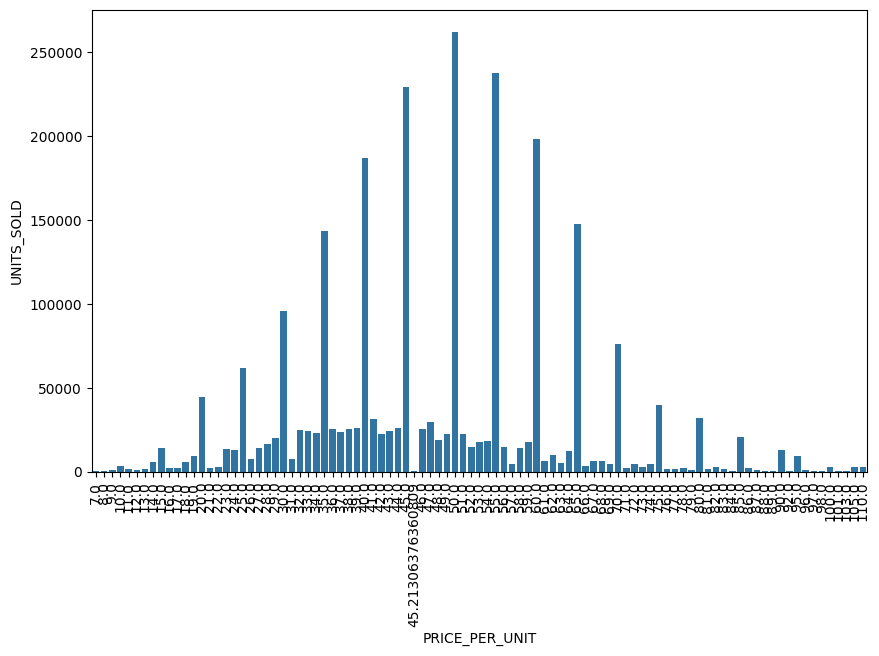

In [232]:
#What average price sells the most units
price_distribution = (
    df_combined
    .groupby("PRICE_PER_UNIT", as_index=False)["UNITS_SOLD"]
    .sum()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=price_distribution,
    x="PRICE_PER_UNIT",
    y="UNITS_SOLD"
)
plt.xticks(rotation=90)

In [233]:
#What operating margin maximizes profit
bins = [0, 0.2, 0.3, 0.4, 0.5, 0.6]

df_combined["Margin Range"] = pd.cut(
    df_combined["OPERATING_MARGIN"],
    bins=bins
)

margin_sales = (
    df_combined
    .groupby("Margin Range", observed=False)["SALES"]
    .sum()
    .reset_index()
)

print(margin_sales)

  Margin Range         SALES
0   (0.0, 0.2]  3.994368e+06
1   (0.2, 0.3]  2.288976e+07
2   (0.3, 0.4]  5.189788e+07
3   (0.4, 0.5]  2.926416e+07
4   (0.5, 0.6]  1.127217e+07


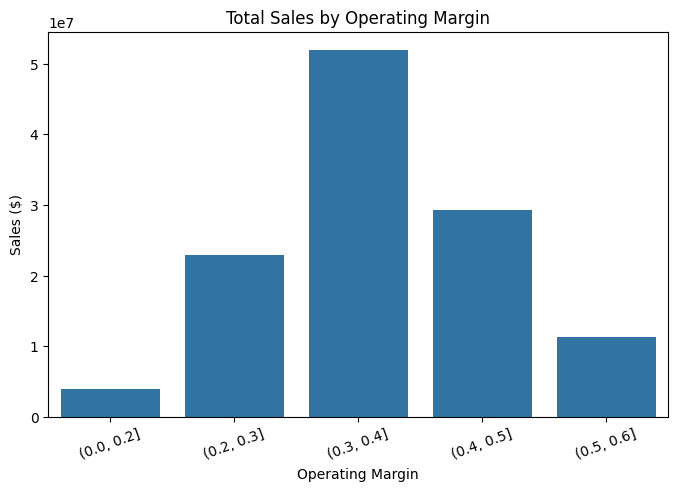

In [234]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=margin_sales,
    x="Margin Range",
    y="SALES"
)

plt.title("Total Sales by Operating Margin")
plt.xlabel("Operating Margin")
plt.ylabel("Sales ($)")
plt.xticks(rotation=20)
plt.show()